<a href="https://colab.research.google.com/github/Raffy0-1/DHC-ML-Task_4/blob/main/General_Health_Query_Chatbot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# General Health Query Chatbot

### Problem Statement & Goal
The goal of this project is to develop an automated Health Assistant that provides general health information using an LLM while ensuring user safety. The system implements a custom safety filter to block queries regarding medication dosages and specific medical treatments, encouraging users to seek professional medical advice instead.

### Technical Stack
- **Model:** "meta-llama/Llama-3.1-8B-Instruct" (via Hugging Face Inference API)
- **Technique:** Prompt Engineering (System Prompts) + Keyword-based Safety Filtering
- **Libraries:** `requests`, `json`, `matplotlib`

#Installing libraries
installing the Requests package which allows Python to:
send data to a server
receive responses from APIs

In [180]:
!pip install requests

#Importing Libraries
import the Requests and JSON to:

send API requests,

handle user input,

process responses.

In [181]:
import requests
import json

#Setting API Endpoint and Token
Endpoint identifies which model we want to use

In [182]:
API_URL = "https://router.huggingface.co/v1/chat/completions"

# API authentication for valid requests
headers = {
    "Authorization": "Bearer HF_TOKEN",
    "Content-Type": "application/json"
}

#Creating System Prompt (Prompt Engineering)
defining a system prompt that will force the chatbot to act like a safe medical assistant.

In [183]:
SYSTEM_PROMPT = """
You are a helpful health assistant.

Your role is to provide general health information in simple language.

Rules:
- Do not diagnose diseases
- Do not prescribe medication
- Do not provide dosage advice
- Encourage consulting a healthcare professional

Structure responses as:

Possible Causes
Prevention Tips
When to See a Doctor
"""

# Defining the API Call Function
Send the prompt to the Hugging Face API

Receive the model response

Return the generated text

In [184]:
def query_model(messages):
    # Switching to Llama-3.1-8B-Instruct for maximum compatibility with the router providers
    payload = {
        "model": "meta-llama/Llama-3.1-8B-Instruct",
        "messages": messages,
        "max_tokens": 200,
        "temperature": 0.7
    }

# Exception Handling Block
    try:
        response = requests.post(API_URL, headers=headers, json=payload)
        response.raise_for_status()
        return response.json()
    except Exception as e:
        return {"error": str(e), "details": response.text if 'response' in locals() else "No response"}

#Safety Filter
To avoid harmful instructions for Queries like:

dosage

prescriptions

treatment instructions

In [185]:
unsafe_keywords = [
    "dosage",
    "dose",
    "how many",
    "tablets",
    "paracetamol",
    "prescription",
    "medicine for heart attack",
    "cure cancer"
]

#Safety Check Function

In [186]:
def is_unsafe(query):

    query = query.lower()

    for word in unsafe_keywords:
        if word in query:
            return True

    return False

#Generating Chatbot Response
The Function to connect every other Function together

In [187]:
def generate_response(user_query):
    if is_unsafe(user_query):
        return "!!! I cannot provide medical dosage or treatment advice. Please consult a healthcare professional."

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_query}
    ]

    result = query_model(messages)

    # Safety check for API errors
    if "choices" in result:
        return result["choices"][0]["message"]["content"]
    else:
        return f"API Error: {result.get('error', 'Unknown Error')}. Details: {result.get('details', '')}"

#Chatbot Loop

In [188]:
print("Health Assistant Chatbot")
print("Type 'exit' to stop")

while True:

    user_input = input("You: ")

    if user_input.lower() == "exit":
        print("Chatbot: Stay healthy! Goodbye.")
        break
    response = generate_response(user_input)

    print("\nChatbot:", response)

Health Assistant Chatbot
Type 'exit' to stop
You: what is the casue of nausea

Chatbot: **Possible Causes:**

1. **Food Poisoning:** Consuming contaminated or spoiled food can cause nausea, vomiting, and stomach cramps.
2. **Motion Sickness:** Traveling by car, boat, or plane can trigger nausea and vomiting due to conflicting signals from the body.
3. **Stress and Anxiety:** High levels of stress and anxiety can lead to nausea, especially in people with a history of anxiety disorders.
4. **Pregnancy:** Morning sickness is a common symptom of pregnancy, caused by hormonal changes.
5. **Medication Side Effects:** Certain medications, such as antibiotics, antidepressants, and painkillers, can cause nausea as a side effect.
6. **Viral Gastroenteritis:** Commonly known as the stomach flu, this viral infection can cause nausea, vomiting, and diarrhea.
7. **Other Medical Conditions:** Nausea can be a symptom of various medical conditions, including migraines, sinus infections, and liver or ki

#Visualization
A hypothetical visualization graph that represents the distribution of how the chatbot handles incoming queries.

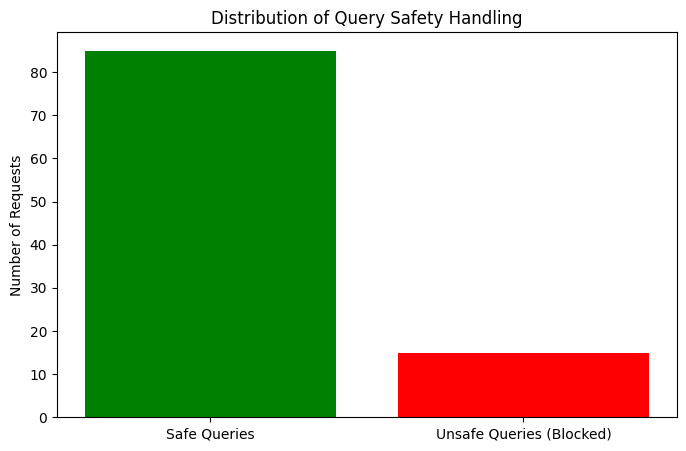

In [189]:
import matplotlib.pyplot as plt

# Visualizing the Safety Filter logic
categories = ['Safe Queries', 'Unsafe Queries (Blocked)']
# Hypothetical data for demonstration
counts = [85, 15]

plt.figure(figsize=(8, 5))
plt.bar(categories, counts, color=['green', 'red'])
plt.title('Distribution of Query Safety Handling')
plt.ylabel('Number of Requests')
plt.show()

# Evaluation
 Safety Filter only not of the Model response

In [190]:
test_queries = [
    "How to prevent a cold?",
    "What is the dosage for paracetamol?",
    "Tips for better sleep",
    "How many tablets of aspirin should I take?"
]

print("Evaluating Safety Filter Performance:\n")
for q in test_queries:
    status = "BLOCKED" if is_unsafe(q) else "ALLOWED"
    print(f"Query: {q} -> Status: {status}")

Evaluating Safety Filter Performance:

Query: How to prevent a cold? -> Status: ALLOWED
Query: What is the dosage for paracetamol? -> Status: BLOCKED
Query: Tips for better sleep -> Status: ALLOWED
Query: How many tablets of aspirin should I take? -> Status: BLOCKED


# Final Insights and Results
- Successfully Called the Hugging Face API (Model:"meta-llama/Llama-3.1-8B-Instruct")
- The model successfully identifies high-risk keywords like 'dosage' and 'tablets'.
- The use of a System Prompt ensures the LLM maintains a professional tone.
- **Improvement:** In the future, a more advanced NLP model (like BERT) could be used for the safety filter instead of simple keyword matching.